In [4]:
!pip install seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/saas_customers_cleaned.csv",
                  parse_dates=["Subscription_Date", "Renewal_Date", "Cancellation_Date"])
print(df.shape)
df.head()

(35000, 22)


,Customer_ID,Age,Country,Industry,Company_Size,Subscription_Plan,Subscription_Date,Renewal_Date,Monthly_Fee,Discount_Percent,...,Support_Tickets,Login_Frequency_Per_Week,Usage_Hours_Monthly,Feature_Usage_Percent,Upgrade_Count,Downgrade_Count,Cancellation_Date,Customer_Status,Customer_Satisfaction,Lifetime_Value
0,CUST100000,56,Canada,Marketing/Media,Small,Basic,2024-02-10,NaT,15.87,7.2,...,1,6.3,2.8,30.2,0,0,2024-11-28,Churned,6.3,141.27
1,CUST100001,46,India,Healthcare,Small,Premium,2024-05-04,2025-05-04,110.60,17.4,...,3,2.5,18.4,46.6,1,0,NaT,Active,5.9,1821.71
2,CUST100002,32,India,Finance,Small,Basic,2023-08-12,2024-08-11,15.27,12.4,...,6,2.5,9.8,32.8,1,0,NaT,Active,6.0,383.63
3,CUST100003,60,Germany,Marketing/Media,Medium,Premium,2025-03-23,NaT,98.04,4.6,...,3,6.8,26.0,55.9,0,0,2025-09-10,Churned,5.3,525.42
4,CUST100004,25,Australia,Technology,Medium,Standard,2025-03-23,2026-03-23,40.68,4.2,...,4,7.1,16.4,56.1,0,0,NaT,Active,6.1,363.60


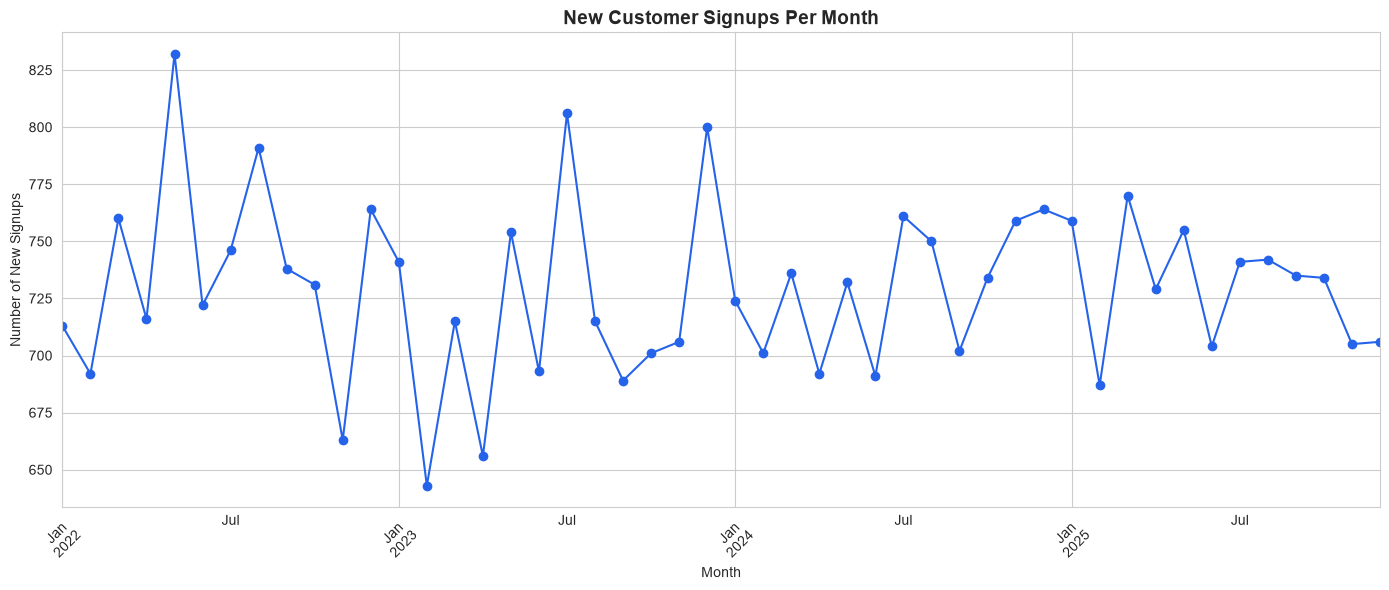

In [2]:
monthly_signups = df.groupby(df["Subscription_Date"].dt.to_period("M")).size()

plt.figure(figsize=(14, 6))
monthly_signups.plot(kind="line", marker="o", color="#2563eb")
plt.title("New Customer Signups Per Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of New Signups")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/charts/01_signups_over_time.png", dpi=150)
plt.show()

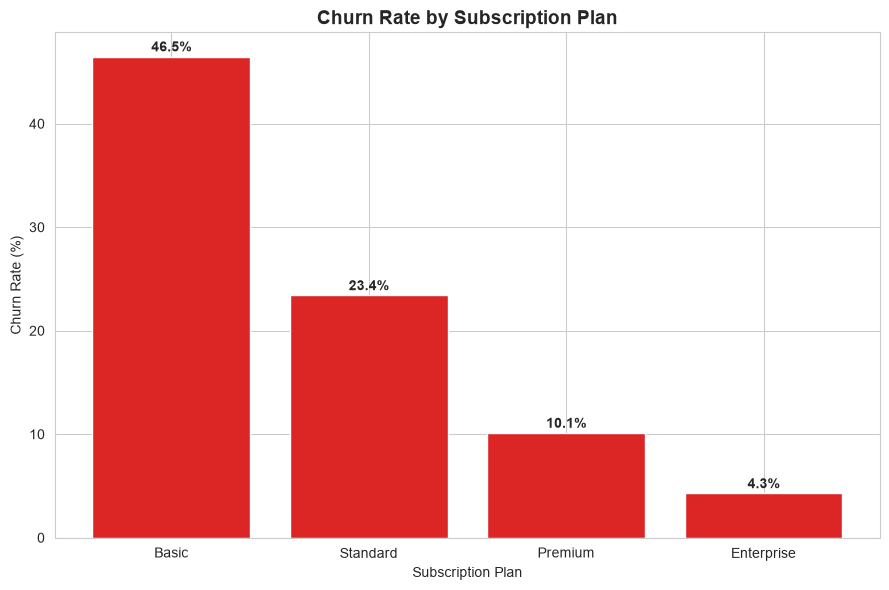

In [3]:
churn_by_plan = df.groupby("Subscription_Plan")["Customer_Status"].apply(
    lambda x: (x == "Churned").mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
bars = plt.bar(churn_by_plan.index, churn_by_plan.values, color="#dc2626")
plt.title("Churn Rate by Subscription Plan", fontsize=14, fontweight="bold")
plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%",
             ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../images/charts/02_churn_by_plan.png", dpi=150)
plt.show()

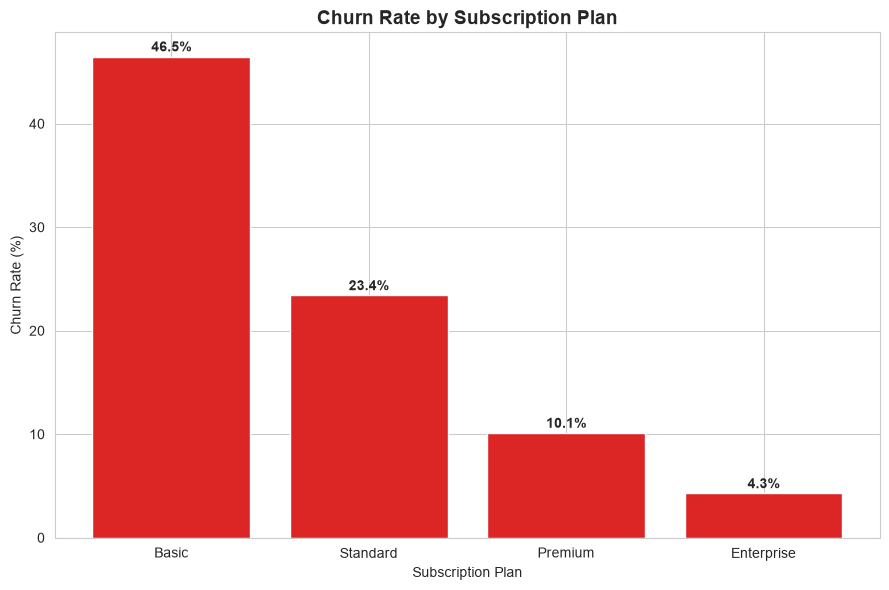

In [5]:
churn_by_plan = df.groupby("Subscription_Plan")["Customer_Status"].apply(
    lambda x: (x == "Churned").mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
bars = plt.bar(churn_by_plan.index, churn_by_plan.values, color="#dc2626")
plt.title("Churn Rate by Subscription Plan", fontsize=14, fontweight="bold")
plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%",
             ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../images/charts/02_churn_by_plan.png", dpi=150)
plt.show()

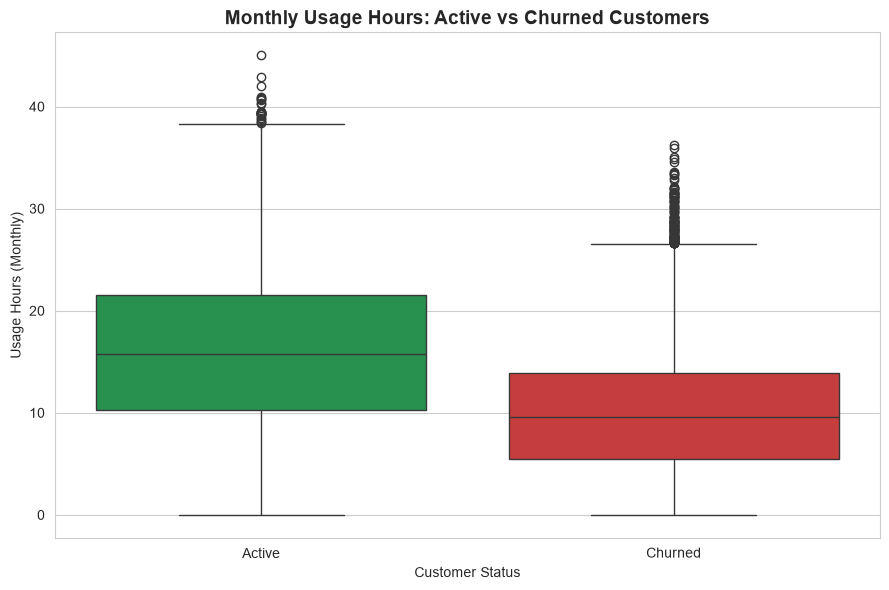

In [8]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Customer_Status", y="Usage_Hours_Monthly",
            order=["Active", "Churned"], hue="Customer_Status",
            hue_order=["Active", "Churned"], palette=["#16a34a", "#dc2626"],
            legend=False)
plt.title("Monthly Usage Hours: Active vs Churned Customers", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Usage Hours (Monthly)")
plt.tight_layout()
plt.savefig("../images/charts/03_usage_vs_churn.png", dpi=150)
plt.show()

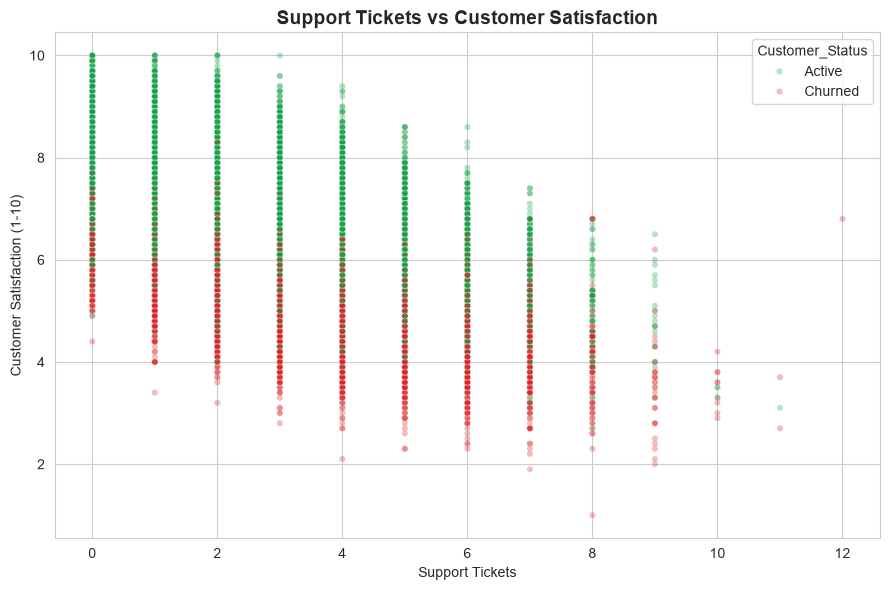

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Support_Tickets", y="Customer_Satisfaction",
                 hue="Customer_Status", hue_order=["Active", "Churned"],
                 palette=["#16a34a", "#dc2626"], alpha=0.3, s=20)
plt.title("Support Tickets vs Customer Satisfaction", fontsize=14, fontweight="bold")
plt.xlabel("Support Tickets")
plt.ylabel("Customer Satisfaction (1-10)")
plt.tight_layout()
plt.savefig("../images/charts/04_support_vs_satisfaction.png", dpi=150)
plt.show()

                   Customers  Avg_LTV  Churn_Rate
Marketing_Channel                                
Affiliate               2776  1497.08       26.51
Referral                4915  1485.79       27.02
Paid Ads                8335  1466.78       26.84
Organic Search          7700  1461.97       27.57
Social Media            7115  1461.06       27.62
Email Campaign          4159  1449.85       25.87


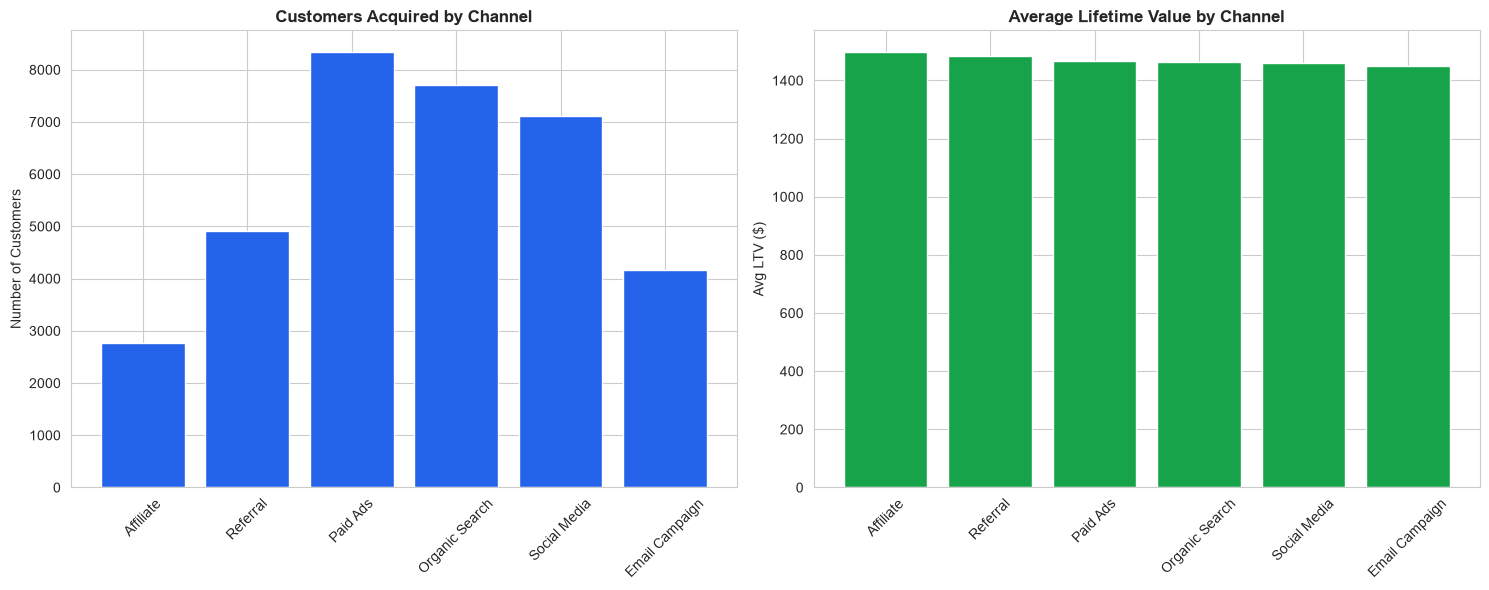

In [10]:
channel_stats = df.groupby("Marketing_Channel").agg(
    Customers=("Customer_ID", "count"),
    Avg_LTV=("Lifetime_Value", "mean"),
    Churn_Rate=("Customer_Status", lambda x: (x == "Churned").mean() * 100)
).sort_values("Avg_LTV", ascending=False)

print(channel_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(channel_stats.index, channel_stats["Customers"], color="#2563eb")
axes[0].set_title("Customers Acquired by Channel", fontweight="bold")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(channel_stats.index, channel_stats["Avg_LTV"], color="#16a34a")
axes[1].set_title("Average Lifetime Value by Channel", fontweight="bold")
axes[1].set_ylabel("Avg LTV ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../images/charts/05_marketing_channel_performance.png", dpi=150)
plt.show()

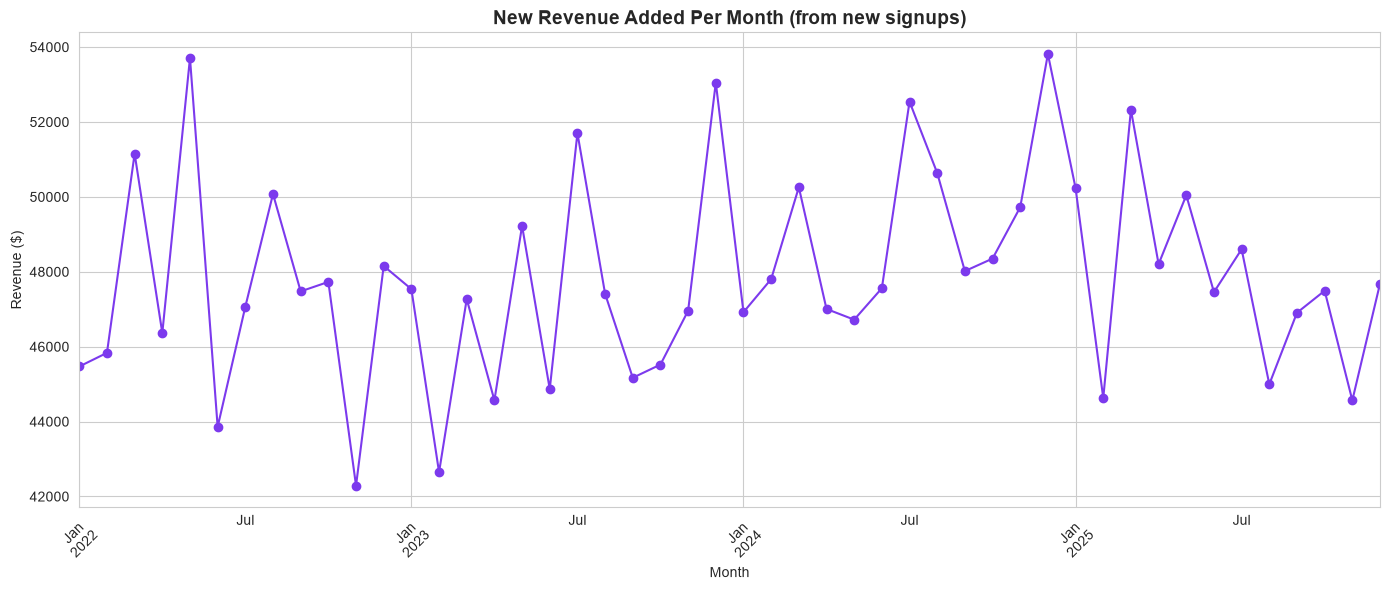

In [11]:
df["Revenue"] = df["Monthly_Fee"] * (1 - df["Discount_Percent"] / 100)

monthly_revenue = df.groupby(df["Subscription_Date"].dt.to_period("M"))["Revenue"].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind="line", marker="o", color="#7c3aed")
plt.title("New Revenue Added Per Month (from new signups)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/charts/06_revenue_trend.png", dpi=150)
plt.show()

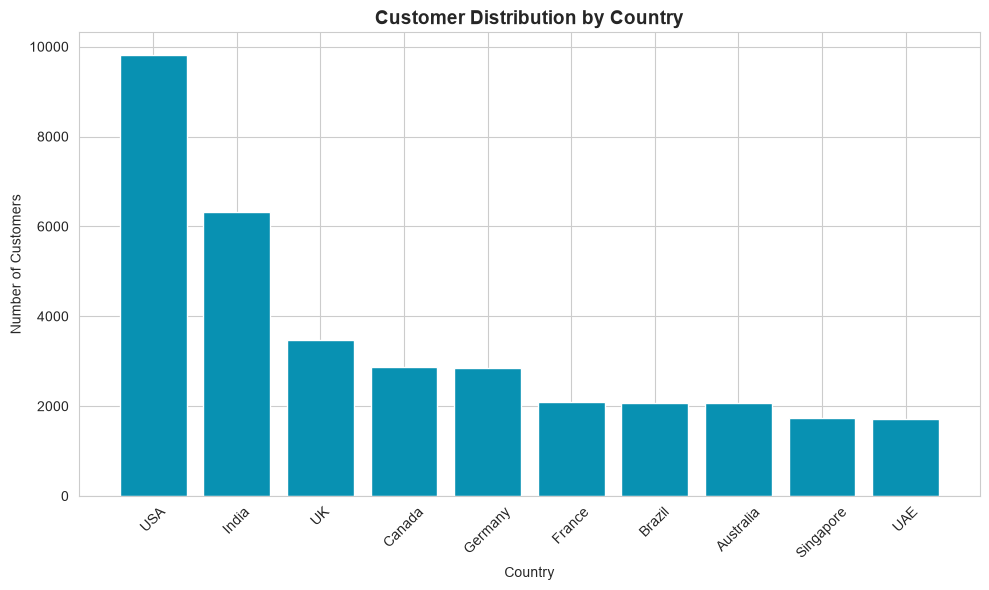

In [12]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(country_counts.index, country_counts.values, color="#0891b2")
plt.title("Customer Distribution by Country", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/charts/07_country_distribution.png", dpi=150)
plt.show()

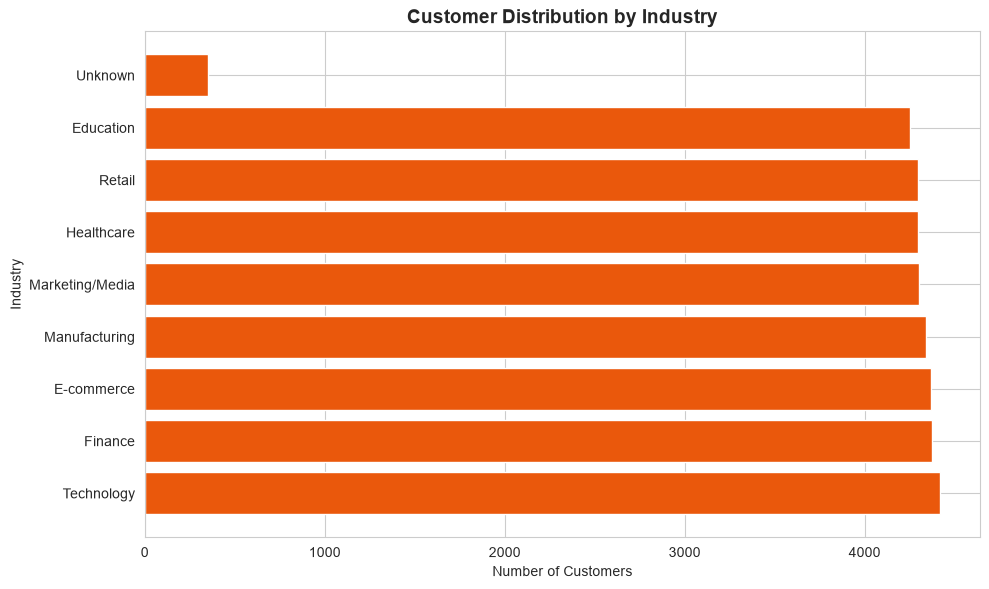

In [13]:
industry_counts = df["Industry"].value_counts()

plt.figure(figsize=(10, 6))
plt.barh(industry_counts.index, industry_counts.values, color="#ea580c")
plt.title("Customer Distribution by Industry", fontsize=14, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("Industry")
plt.tight_layout()
plt.savefig("../images/charts/08_industry_distribution.png", dpi=150)
plt.show()

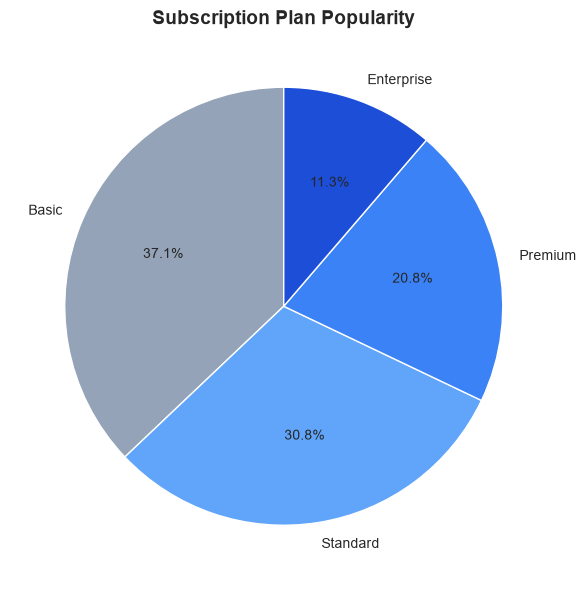

In [14]:
plan_counts = df["Subscription_Plan"].value_counts()

plt.figure(figsize=(9, 6))
colors = ["#94a3b8", "#60a5fa", "#3b82f6", "#1d4ed8"]
plt.pie(plan_counts.values, labels=plan_counts.index, autopct="%1.1f%%",
        colors=colors, startangle=90)
plt.title("Subscription Plan Popularity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/charts/09_plan_popularity.png", dpi=150)
plt.show()